In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import precision_recall_curve, confusion_matrix


df = pd.read_csv('../Data/input/creditcard.csv') 

X = df.drop(columns=["Class"])
y = df["Class"]

# divisão teste e treino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Normalização com RobustScaler
scaler = RobustScaler()
cols_to_scale = ["Time", "Amount"]

scaler.fit(X_train[cols_to_scale])

X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# 4. Aplicação do SMOTE para balanceamento
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [10]:
y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [12]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [2]:
print(f"Fraudes no treino (balanceado): {y_train_smote.sum()}")
print(f"Total de amostras no treino: {len(X_train_smote)}")

Fraudes no treino (balanceado): 227451
Total de amostras no treino: 454902


In [13]:
# Modelo DecisionTree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
# max_depth=5: para evitar overfitting

dt_model.fit(X_train_smote, y_train_smote)


DecisionTreeClassifier(max_depth=5, random_state=42)

-  Avaliando o modelo:

In [4]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1] # Probabilidades para calcular o AUC

print(classification_report(y_test, y_pred_dt, digits=4))
print("AUC:", roc_auc_score(y_test, y_prob_dt))

              precision    recall  f1-score   support

           0     0.9998    0.9617    0.9804     56864
           1     0.0384    0.8878    0.0736        98

    accuracy                         0.9616     56962
   macro avg     0.5191    0.9247    0.5270     56962
weighted avg     0.9981    0.9616    0.9788     56962

AUC: 0.9258119803211098


- Precision-recall curve

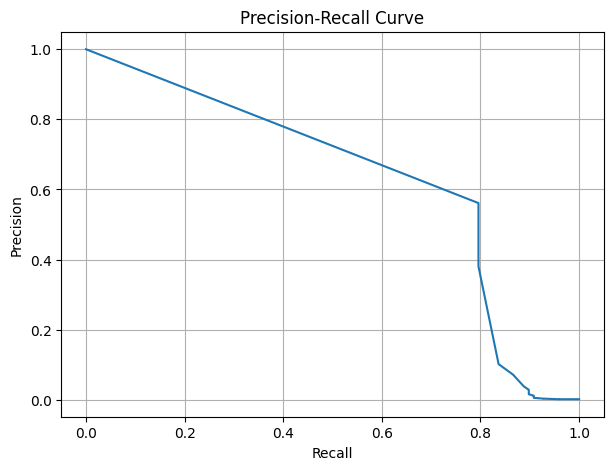

In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_dt)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [15]:
df_metrics = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precision[:-1],  # Remove last element to match thresholds length
    'Recall': recall[:-1]
})
df_metrics


,Threshold,Precision,Recall
0,0.000000,0.001720,1.000000
1,0.001672,0.001711,0.979592
2,0.005000,0.001680,0.959184
3,0.005556,0.001686,0.959184
4,0.006557,0.001693,0.959184
5,0.011407,0.003219,0.928571
6,0.040415,0.003226,0.928571
7,0.049672,0.005574,0.908163
8,0.055005,0.010315,0.908163
9,0.145208,0.011496,0.908163


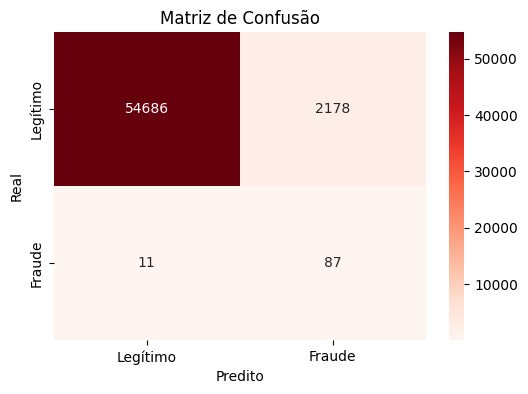

In [6]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legítimo','Fraude'],
            yticklabels=['Legítimo','Fraude'])
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

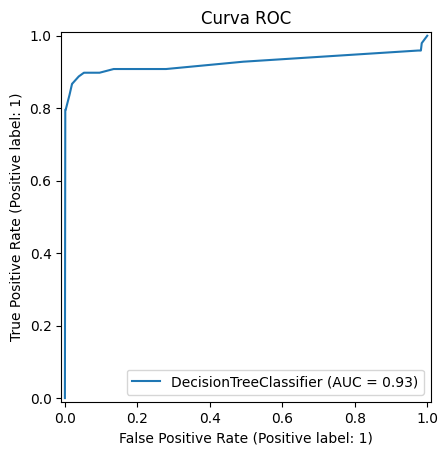

In [7]:
# Curva ROC
RocCurveDisplay.from_estimator(dt_model, X_test, y_test)
plt.title("Curva ROC""")
plt.show()